# Feature engineering

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

from heart_failure.config.config import (
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    HEART_DISEASE,
    SEX,
    EXERCISE_ANGINA,
    FASTING_BS,
    RESTING_ECG
)
from heart_failure.dataset import split_data
from heart_failure.config.features import RANDOM_STATE, TE_CV
from heart_failure.features import get_fe_pipeline
from heart_failure.feature_selection import select_by_vif, find_best_corr_threshold
from heart_failure.plots import plot_corr_matrix, kdeplot_features_by_target

In [2]:
df = pd.read_csv(INTERIM_DATA_DIR / "heart.csv")

y = df[HEART_DISEASE]
X = df.drop(columns=[HEART_DISEASE])

X_train, y_train, X_val, y_val, X_test, y_test = split_data(
    X, y, stratify_func=lambda X, y: pd.concat([X[[SEX]], y], axis=1)
)

### Feature implementing

In [3]:
cv = StratifiedKFold(n_splits=TE_CV, shuffle=True, random_state=RANDOM_STATE)
fe_pipeline = get_fe_pipeline(cv, n_bins=8, rename_features=True)

In [4]:
X_train = fe_pipeline.fit_transform(X_train, y_train)
X_test = fe_pipeline.transform(X_test)

In [5]:
X_train.head()

,target_encoder__RestingECG,target_encoder__ChestPainType,target_encoder__ST_Slope,binary_encoder__Sex,binary_encoder__FastingBS,binary_encoder__ExerciseAngina,binner_Age__Age,binner_Cholesterol__Cholesterol,remainder__RestingBP,remainder__MaxHR,...,remainder__Oldpeak_Cholesterol_ST_Slope_te,remainder__MaxHR_RestingECG_te,remainder__Age_Cholesterol_Sex_te,remainder__ChestPainType_Sex_te,remainder__ST_Slope_Sex_te,remainder__ChestPainType_RestingECG_te,remainder__ST_Slope_RestingECG_te,remainder__Sex_RestingECG_te,remainder__ExerciseAngina_RestingECG_te,remainder__Oldpeak_RestingECG_te
839,0.521817,0.138691,0.839519,1.0,0.0,0.0,0,1,135.0,132,...,0.792238,0.618826,0.300436,0.206661,0.900820,0.113545,0.850629,0.579891,0.332658,0.325007
351,0.629347,0.795385,0.182937,1.0,0.0,1.0,0,2,140.0,140,...,0.580986,0.542095,0.521255,0.828384,0.229814,0.767964,0.222329,0.709271,0.883299,0.742779
398,0.521817,0.795385,0.182937,1.0,1.0,1.0,2,2,165.0,122,...,0.596987,0.599322,0.801147,0.837741,0.257855,0.818932,0.152562,0.609007,0.831947,0.683044
563,0.629347,0.795385,0.839519,1.0,1.0,1.0,2,3,144.0,160,...,0.912481,0.267969,0.725470,0.829748,0.894383,0.780720,0.884250,0.716068,0.869303,0.878328
190,0.629347,0.795385,0.182937,1.0,0.0,0.0,1,4,180.0,120,...,0.112236,0.663341,0.754830,0.829748,0.235258,0.780720,0.230671,0.716068,0.420540,0.375968


In [6]:
X_train.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binary_encoder__Sex              0
binary_encoder__FastingBS        0
dtype: int64

In [7]:
X_test.isna().sum().sort_values(ascending=False).head()

target_encoder__RestingECG       0
target_encoder__ChestPainType    0
target_encoder__ST_Slope         0
binary_encoder__Sex              0
binary_encoder__FastingBS        0
dtype: int64

### Feature correlation

In [8]:
train = X_train.merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()

In [9]:
plot_corr_matrix(corr_df, width=800, height=800, fontsize=9)

Multicollinearity is present. When we calculate gender target encoding (ex.) into bins of some other feature, the probability of class 1 appearing can be repeated across splits by different features. Therefore, they are highly correlated with each other.

The features ChestPainType (te) and FastingBS_ChestPainType (te); ST_Slope (te) and FastingBS_ST_Slope are also highly correlated. This is explained by the fact that FastingBS is not a significant indicator of the disease, but simply represents the age group most susceptible to the disease.

In [10]:
thresholds = [0.02, 0.05, 0.1, 0.15]

best_threshold, thr_result = find_best_corr_threshold(X_train, y_train, thresholds)
thr_result

,threshold,features,score_mean,score_std
3,0.15,22,0.813482,0.053931
2,0.10,22,0.813482,0.053931
1,0.05,24,0.808671,0.057258
0,0.02,24,0.808671,0.057258


In [11]:
low_correlated = corr_df[corr_df[HEART_DISEASE].abs() < best_threshold].index.to_list()
low_correlated

['target_encoder__RestingECG', 'remainder__RestingBP']

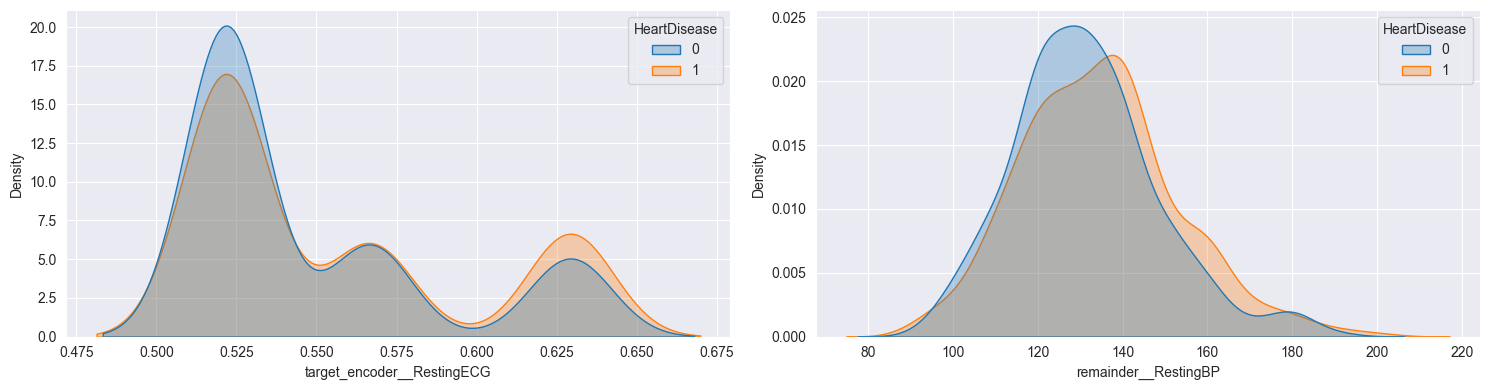

In [12]:
kdeplot_features_by_target(train, low_correlated, HEART_DISEASE)

For RestingECG, the correlation was expected to be small (the percentages initially didn't vary much across categories).

In [13]:
X_train = X_train.drop(columns=low_correlated)
X_test = X_test.drop(columns=low_correlated)

In [14]:
remaining_cols, drop_order = select_by_vif(X_train, y_train)
drop_order

remainder__ExerciseAngina_RestingECG_te    834.134549
target_encoder__ST_Slope                   318.641938
target_encoder__ChestPainType              237.885482
remainder__Sex_RestingECG_te               185.844080
remainder__ChestPainType_Sex_te            120.308391
remainder__ST_Slope_Sex_te                  86.737724
remainder__Age_MaxHR_ratio                  58.699590
remainder__Oldpeak_ChestPainType_te         51.696746
remainder__Age_Cholesterol_Sex_te           26.150536
remainder__ST_Slope_RestingECG_te           22.861117
remainder__Oldpeak_RestingECG_te            21.375798
remainder__MaxHR_RestingECG_te              10.111138
dtype: float64

In [15]:
remaining_cols

['binary_encoder__Sex',
 'binary_encoder__FastingBS',
 'binary_encoder__ExerciseAngina',
 'binner_Age__Age',
 'binner_Cholesterol__Cholesterol',
 'remainder__MaxHR',
 'remainder__Oldpeak',
 'remainder__conjunctive_rules',
 'remainder__Oldpeak_Cholesterol_ST_Slope_te',
 'remainder__ChestPainType_RestingECG_te']

In [16]:
train = X_train[remaining_cols].merge(y_train, left_index=True, right_index=True)
corr_df = train.corr()
plot_corr_matrix(corr_df, width=600, height=600, fontsize=9)

In [17]:
pd.Series(remaining_cols).to_csv(PROCESSED_DATA_DIR / 'remaining_cols.csv', index=False)

### Binned features

Target correlation with binned features has increased. Class distributions do not overlap. Binning definitely helps for cholesterol, which has abnormally high values. Age and MaxHR also have rare high/low values. This helps at least linear models.

In [18]:
binned = X_train.columns[X_train.columns.str.startswith("binner")]
X_train_raw = df.loc[X_train.index]

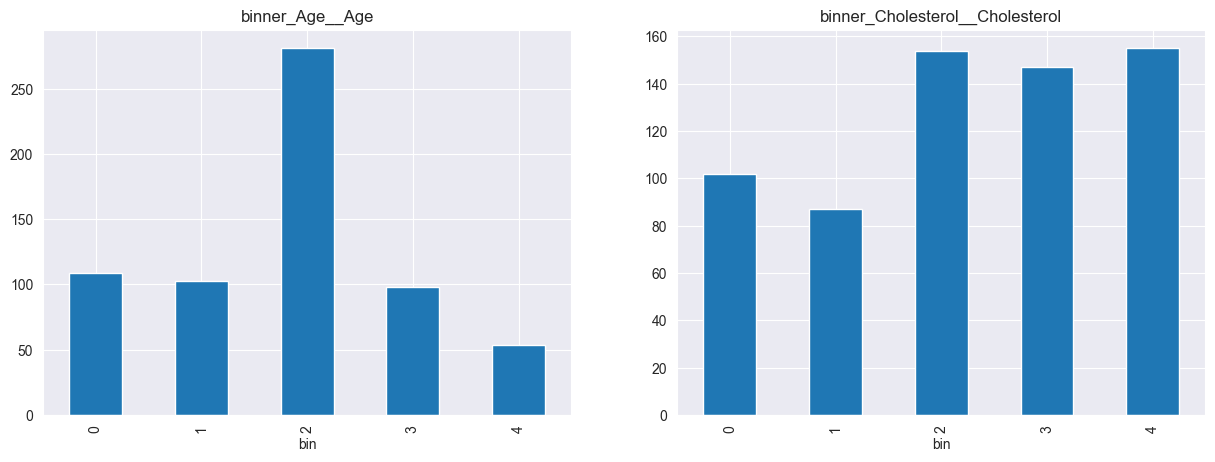

In [24]:
fig, axes = plt.subplots(1, len(binned), figsize=(15, 5))

for col, ax in zip(binned, axes):
    raw_cal = col.rsplit("__", 1)[1]
    tmp = pd.DataFrame({raw_cal: X_train_raw[raw_cal], "bin": X_train[col]})
    tmp["bin"].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col)

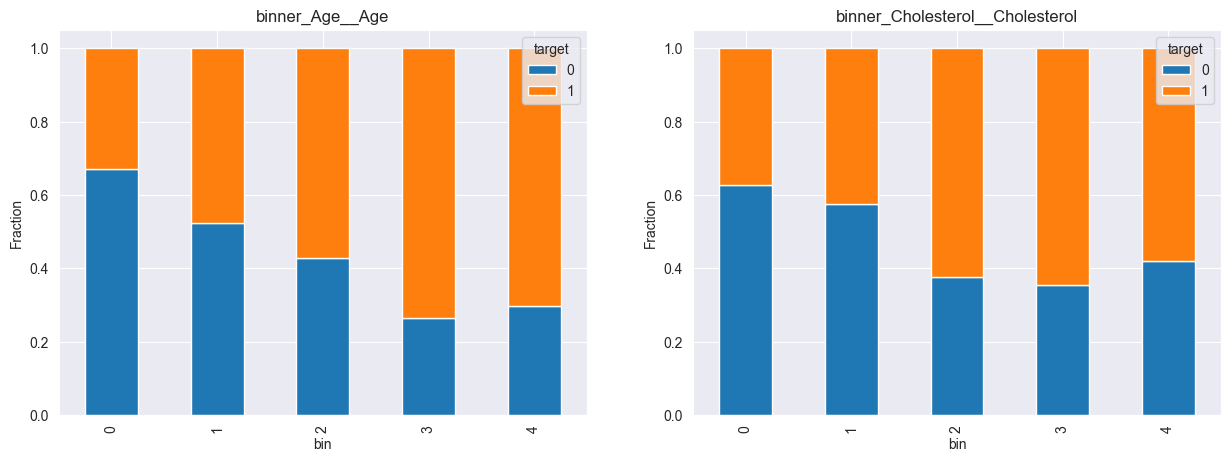

In [23]:
fig, axes = plt.subplots(1, len(binned), figsize=(15, 5))

for col, ax in zip(binned, axes):
    raw_col = col.rsplit("__", 1)[1]
    tmp = pd.DataFrame({
        raw_col: X_train_raw[raw_col], "bin": X_train[col], "target": y_train,
    })

    rate = pd.crosstab(tmp["bin"], tmp["target"], normalize="index").sort_index()
    rate.plot(kind="bar", stacked=True, ax=ax)
    ax.set_ylabel("Fraction")
    ax.set_title(col)

Age and Cholesterol are non-monotonic, since the disease percentage in the last bin is lower than in the previous ones.

## Unconsidered points

- [Unaccounted diseases of conjunctive_rules feature](../reports/conj_rules_unaccounted_diseases.md)
- [Count of cases in cross-features subgroups](../reports/cross_features_count.md)
- [RestingECG cross-features](../reports/resting_ecg_cross_features.md)